In [ ]:
!pip3 install -U ucimlrepo;

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneOut, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.ensemble import RandomForestClassifier as RF

In [ ]:
# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

## Milestone 1

In [ ]:
types_of_var = cdc_diabetes_health_indicators.variables.type[2:]
# getting rid of ID and Diabetes_binary with [2:] since they are not included in X, the features

number_of_qualitative = 0
number_of_quantitative = 0
index = 0

varQualitative = np.empty(len(X)).tolist()
varQuantitative = np.empty(len(X)).tolist()

# print(X.columns)
# print(cdc_diabetes_health_indicators.variables)

# demonstrate qualitative/quantitative variables:
for i in types_of_var:
  varName = X.columns[index]

  if (i == "Categorical" or i == "Binary"):
    varQualitative[number_of_qualitative] = varName
    number_of_qualitative += 1
    index += 1
  else:
    varQuantitative[number_of_quantitative] = varName
    number_of_quantitative += 1
    index += 1

# shrink the lists so they don't have empty values:
varQualitative = varQualitative[:number_of_qualitative]
varQuantitative = varQuantitative[:number_of_quantitative]

print(f"Number of qualitative variables: {number_of_qualitative}")
print(varQualitative)

print(f"Number of quantitative variables: {number_of_quantitative}")
print(varQuantitative)

# One interesting qualitative feature: HighChol
print(f"\n\nNumber of patients in the dataset: {X.shape[0]}")
print(X.HighChol.value_counts())


Number of qualitative variables: 14
['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Number of quantitative variables: 7
['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


Number of patients in the dataset: 253680
HighChol
0    146089
1    107591
Name: count, dtype: int64


## Milestone 2

In [ ]:
# Aim to predict the binary value indicating having or not having diabetes.

for name in varQuantitative:
  min = np.min(X[name])
  max = np.max(X[name])
  mean = np.mean(X[name])
  median = np.median(X[name])
  std = np.std(X[name])
  print(f"{name}:\n Min: {min:.2f}\n Max: {max:.2f}\n Mean: {mean:.2f}\n Median: {median:.2f}\n STD: {std:.2f}")

BMI:
 Min: 12.00
 Max: 98.00
 Mean: 28.38
 Median: 27.00
 STD: 6.61
GenHlth:
 Min: 1.00
 Max: 5.00
 Mean: 2.51
 Median: 2.00
 STD: 1.07
MentHlth:
 Min: 0.00
 Max: 30.00
 Mean: 3.18
 Median: 0.00
 STD: 7.41
PhysHlth:
 Min: 0.00
 Max: 30.00
 Mean: 4.24
 Median: 0.00
 STD: 8.72
Age:
 Min: 1.00
 Max: 13.00
 Mean: 8.03
 Median: 8.00
 STD: 3.05
Education:
 Min: 1.00
 Max: 6.00
 Mean: 5.05
 Median: 5.00
 STD: 0.99
Income:
 Min: 1.00
 Max: 8.00
 Mean: 6.05
 Median: 7.00
 STD: 2.07


0.8618535162409334


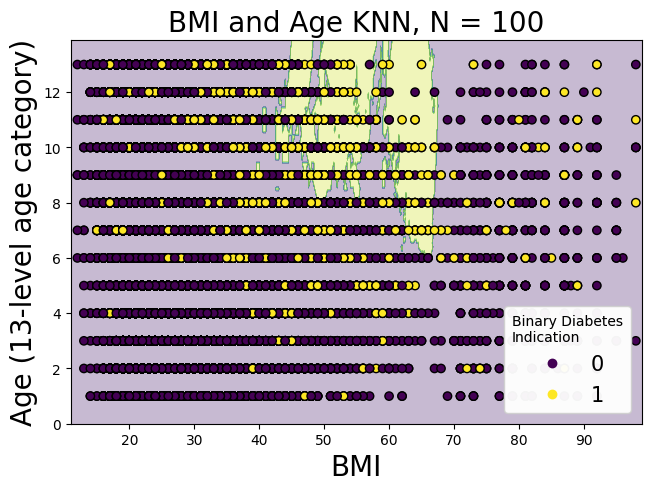

In [ ]:
# Part 1: KNN
n_neighbors = 100
tryingToFixY = y.values.ravel()
featureData = X[["BMI", "Age"]].values

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(featureData, tryingToFixY, test_size=0.2, random_state=42)

# Initialize KNN classifier
knn = KNeighborsClassifier(n_neighbors=n_neighbors)

# Train the model
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# decision boundary:
x_min, x_max = featureData[:, 0].min() - 1, featureData[:, 0].max() + 1
y_min, y_max = featureData[:, 1].min() - 1, featureData[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

XX = np.c_[xx.ravel(), yy.ravel()]
Z = knn.predict(XX)
Z = Z.reshape(xx.shape)

fig,ax = plt.subplots(layout="constrained")

# testing accuracy:
testing_accuracy = np.sum(y_test == y_pred)/len(y_test)
print(testing_accuracy)

### Plot the predictions throughout feature space
plt.contourf(xx, yy, Z, alpha=0.3)

# Part 2:

### Plot all data points, with their true classes
scatter = plt.scatter(featureData[:, 0], featureData[:, 1], c=tryingToFixY, edgecolors='k')
plt.xlabel('BMI',fontsize=20)
plt.ylabel('Age (13-level age category)',fontsize=20)
plt.title(f"BMI and Age KNN, N = {n_neighbors}",fontsize=20)

legend1 = ax.legend(*scatter.legend_elements(), loc="lower right",
                    title="Binary Diabetes\nIndication",fontsize=20*.75)
ax.add_artist(legend1)


In [ ]:
# Work from office hours to investigate dataset:

# y_test_pred = knn.predict(X_test)
# test_accuracy = np.sum(y_test == y_test_pred)/len(y_test)

# y_train_pred = knn.predict(X_train)
# train_accuracy = np.sum(y_train == y_train_pred)/len(y_train)

print(featureData.shape)

print(np.sum(y==0)/len(y))
print(np.sum(y==1)/len(y))

(253680, 2)
Diabetes_binary    0.860667
dtype: float64
Diabetes_binary    0.139333
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [ ]:
# Part 3: PCA

#Standardize the data to have mean 0 and variance 1
scaler = StandardScaler()
scaler.fit(X)
X_standardized = scaler.transform(X)

print("Means: ",np.mean(X_standardized,axis=0))
print("Standard deviations: ",np.std(X_standardized,axis=0))
# Means are roughly equal to 0, and all STD are 1.

Means:  [-1.25034010e-16  5.76993865e-17  1.24585860e-16 -2.50516171e-16
  2.68890345e-17 -4.03335517e-18  4.25743046e-18  5.37780689e-17
  5.60188218e-17 -2.48723569e-17  9.29912442e-17  4.48150574e-17
 -1.79260230e-17  1.71193519e-16  8.96301149e-18  3.45075942e-17
  2.55445827e-17  1.29963667e-16  6.76707367e-17 -8.51486091e-17
  7.17040919e-17]
Standard deviations:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Reduced data size: (253680, 2)


Text(0.5, 1.0, '2nd principal component')

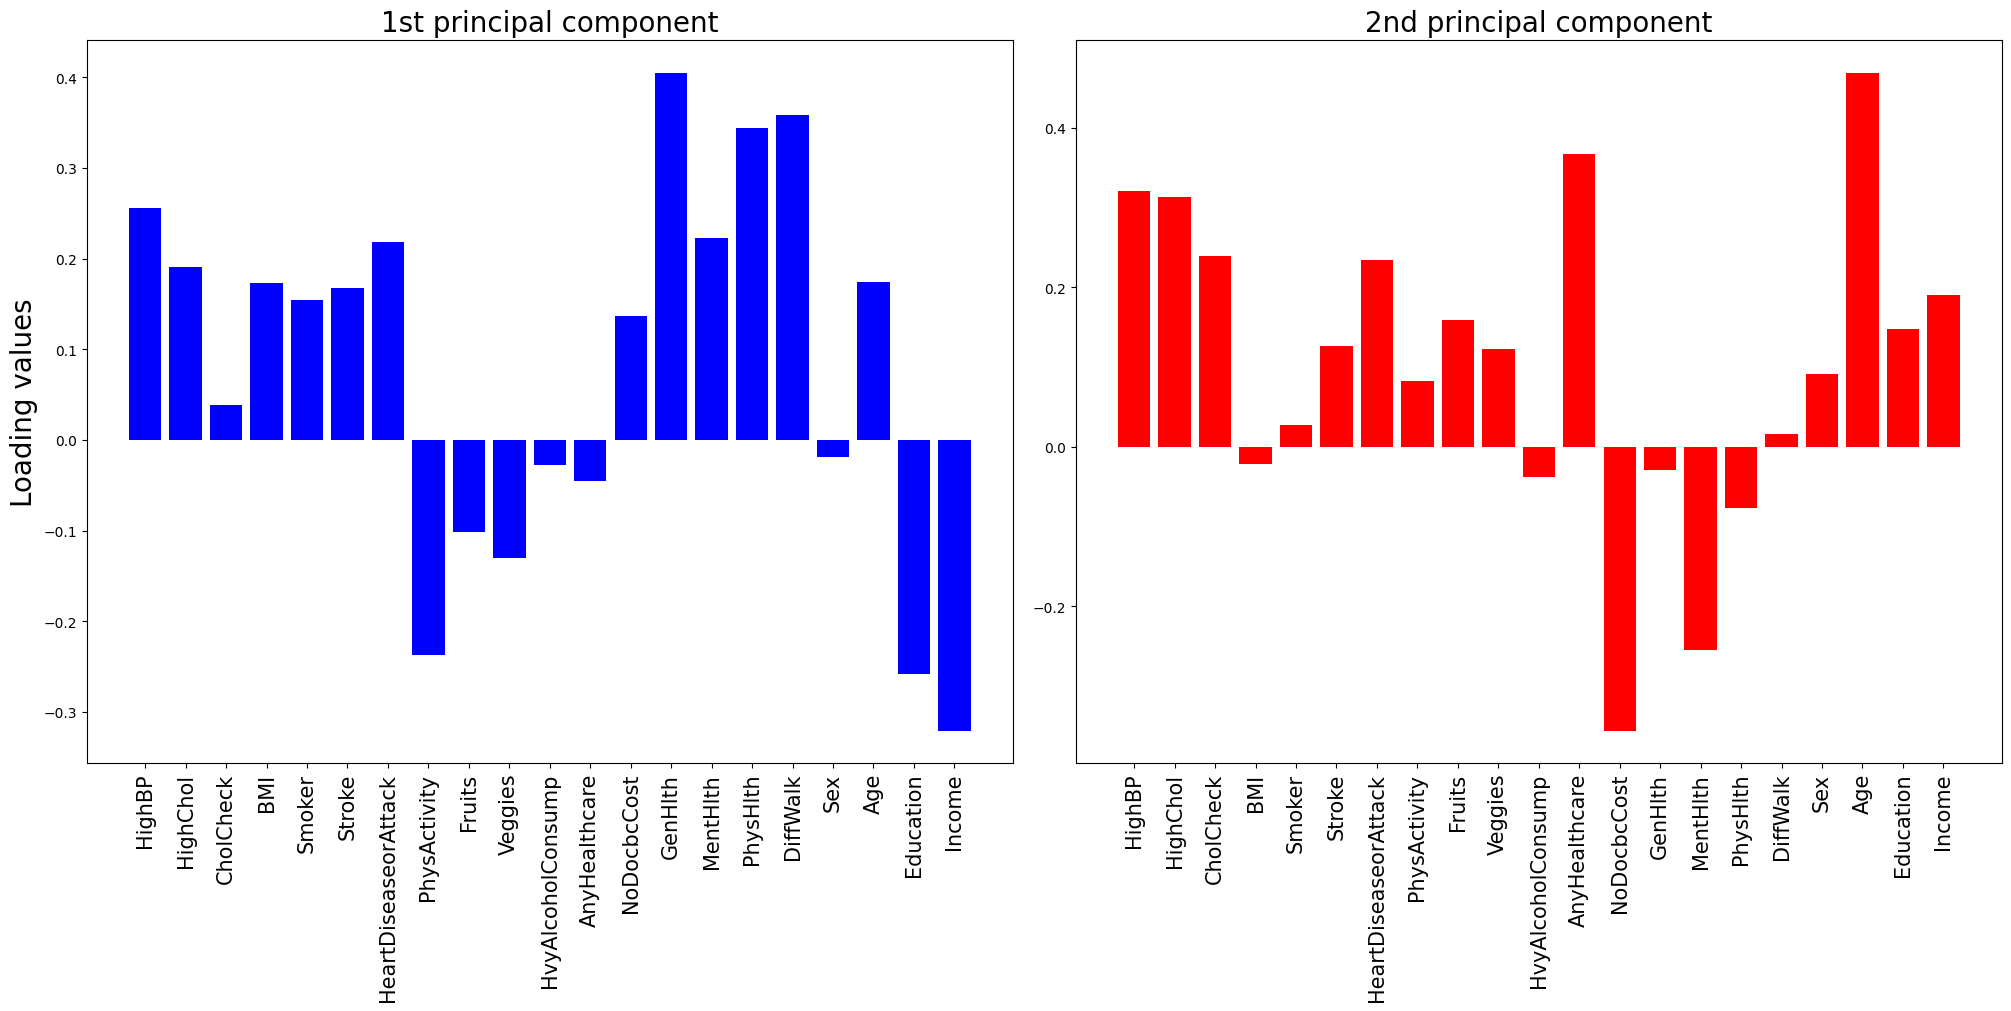

In [ ]:
num_components = 2
pca = PCA(n_components=num_components)

# Fit the PCA model to the standardized data and transform the data
X_reduced = pca.fit_transform(X_standardized)
print("Reduced data size:", X_reduced.shape)

#principal components
components = pca.components_

### plot the principal components
fig,axes = plt.subplots(1,2,layout="constrained",figsize=(20,10))
fontsize=15

axes[0].bar(np.arange(21),components[0,:],color="blue", label = "Principal component 1")
axes[1].bar(np.arange(21),components[1,:],color="red", label = "Principal component 2")

axes[0].set_xticks(ticks = np.arange(21),labels=X.columns,rotation=90,fontsize=20*0.75);
axes[1].set_xticks(ticks = np.arange(21),labels=X.columns,rotation=90,fontsize=20*0.75);
axes[0].set_ylabel("Loading values",fontsize=20)

axes[0].set_title("1st principal component",fontsize=20)
axes[1].set_title("2nd principal component",fontsize=20)

In [ ]:
### Look into explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = np.sum(explained_variance)
print(f"Proportion of variance explained by 1st PC: {explained_variance[0]:.3f}")
print(f"Proportion of variance explained by 2nd PC: {explained_variance[1]:.3f}")
print()
print(f"Cumulative proportion of variance explained by first two PCs: {cumulative_explained_variance:.3f}")

Proportion of variance explained by 1st PC: 0.167
Proportion of variance explained by 2nd PC: 0.084

Cumulative proportion of variance explained by first two PCs: 0.251


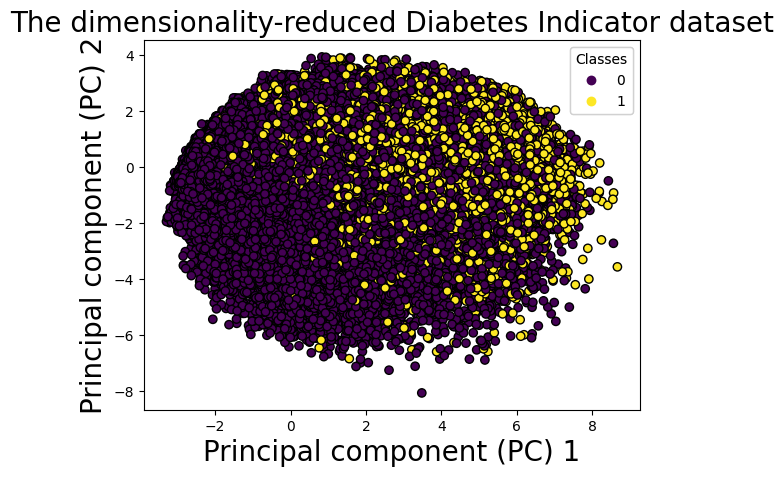

In [ ]:
### Plot dimensionality-reduced data
fig,ax = plt.subplots()
scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=tryingToFixY, edgecolors='k')

ax.set_xlabel('Principal component (PC) 1',fontsize=20)
ax.set_ylabel('Principal component (PC) 2',fontsize=20)
ax.set_title("The dimensionality-reduced Diabetes Indicator dataset",fontsize=20)

# produce a legend with the unique colors from the scatter
legend1 = ax.legend(*scatter.legend_elements(),
                    title="Classes")
ax.add_artist(legend1)

## Milestone 3

In [ ]:
# 1.)
print(f"Number of class 0's: {len(y[y['Diabetes_binary']==0])}")
print(f"Number of class 1's: {len(y[y['Diabetes_binary']==1])}")

## mcc = "most common class"
mcc = y[y['Diabetes_binary']==0]

testing_accuracy = (len(mcc)/len(y))
print(testing_accuracy)

Number of class 0's: 218334
Number of class 1's: 35346
0.8606669820245979


In [ ]:
# 2.)
# Using BMI and Age

features = np.transpose([X['BMI'],X['Age']])
cv = 5

# fixing an error:
y = np.ravel(y)

# cv_err = cross_validate(lda,features,y,cv=cv,scoring="accuracy")

# LDA
lda = LDA()
cv_err_LDA = cross_validate(lda,features,y,cv=cv,scoring="accuracy")
LDAaccuracy = np.mean(cv_err_LDA['test_score'])

print(f"LDA Accuracy: {LDAaccuracy}")

# QDA
qda = QDA()
cv_err_QDA = cross_validate(qda,features,y,cv=cv,scoring="accuracy")
QDAaccuracy = np.mean(cv_err_QDA['test_score'])

print(f"QDA Accuracy: {QDAaccuracy}")

# KNN // this one takes a few minutes to execute
n_neighbors = 100
knn = KNeighborsClassifier(n_neighbors=n_neighbors)
cv_err_KNN = cross_validate(knn,features,y,cv=cv,scoring="accuracy")
KNNaccuracy = np.mean(cv_err_KNN['test_score'])

print(f"KNN Accuracy: {KNNaccuracy}")

LDA Accuracy: 0.858136234626301
QDA Accuracy: 0.8550417849258908
KNN Accuracy: 0.8605171870072532


In [ ]:
# testing code to see why accuracy is all the same

# lda = LDA()
# lda.fit(features,y)
# np.sum(lda.predict(features) != 0)


In [ ]:
features = np.transpose([X['BMI'],X['Age']])
cv = 5

# fixing an error:
y = np.ravel(y)

# Fit random forest
rf = RF(max_features='sqrt', random_state=42)
cv_err_RF = cross_validate(rf,features,y,cv=cv,scoring="accuracy")
RFaccuracy = np.mean(cv_err_RF['test_score'])

print(f"Random Forest Accuracy: {RFaccuracy}")

Random Forest Accuracy: 0.8599810785241248


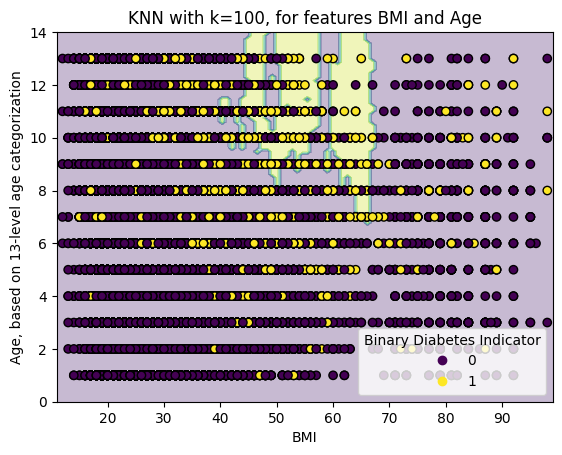

In [ ]:
# 3.)
features = np.transpose([X['BMI'],X['Age']])

knn = KNeighborsClassifier(n_neighbors=100)
knn.fit(features,y)

x_min, x_max = features[:, 0].min() - 1, features[:, 0].max() + 1
y_min, y_max = features[:, 1].min() - 1, features[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
XX = np.c_[xx.ravel(), yy.ravel()]

Zknn = knn.predict(XX)
Zknn = Zknn.reshape(xx.shape)

plt.contourf(xx, yy, Zknn, alpha=0.3)
plt.scatter(features[:, 0], features[:, 1], c=y, edgecolors='k')
plt.title("KNN with k=100, for features BMI and Age")
plt.xlabel("BMI")
plt.ylabel("Age, based on 13-level age categorization")
plt.legend(*scatter.legend_elements(),
            title="Binary Diabetes Indicator",
            loc="lower right")
